# Synthetic experiments

In [ ]:
from boundary_trace import GroupScoreDistribution, trace_intersection
from plotting import plot_feasible_regions, styled_boxplot
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

## Setup and boundary tracing

In [ ]:
# Define synthetic score distributions

scores0  = [0.1, 0.2, 0.5, 0.7, 0.9]
weights0 = [0.1, 0.3, 0.3, 0.15, 0.15]
dist0 = GroupScoreDistribution(scores0, weights0, name='Synth 0')

scores1a  = [0.12, 0.3, 0.85]
weights1a = [0.15, 0.45, 0.4]
dist1a = GroupScoreDistribution(scores1a, weights1a, name='Synth 1a')

scores1b  = [0.2, 0.3, 0.75]
weights1b = [0.3, 0.5, 0.2]
dist1b = GroupScoreDistribution(scores1b, weights1b, name='Synth 1b')

prob_a1 = 0.5

In [ ]:
# Trace intersection boundaries

result_a = trace_intersection(dist0, dist1a, prob_a1)
result_b = trace_intersection(dist0, dist1b, prob_a1)

print(result_a)
print(result_b)

TraceResult(
  A=0: Synth 0,
  A=1: Synth 1a,
  prob_a1 = 0.5000,
  pi_agg  = 0.4765,
  max_acc:  value = 0.7239,
            p = 0.8000, q = 0.3143
  min_dsep: value = 0.0268,
            p = 0.8000, q = 0.3143
)
TraceResult(
  A=0: Synth 0,
  A=1: Synth 1b,
  prob_a1 = 0.5000,
  pi_agg  = 0.4100,
  max_acc:  value = 0.7247,
            p = 0.6976, q = 0.2612
  min_dsep: value = 0.0928,
            p = 0.7500, q = 0.2969
)


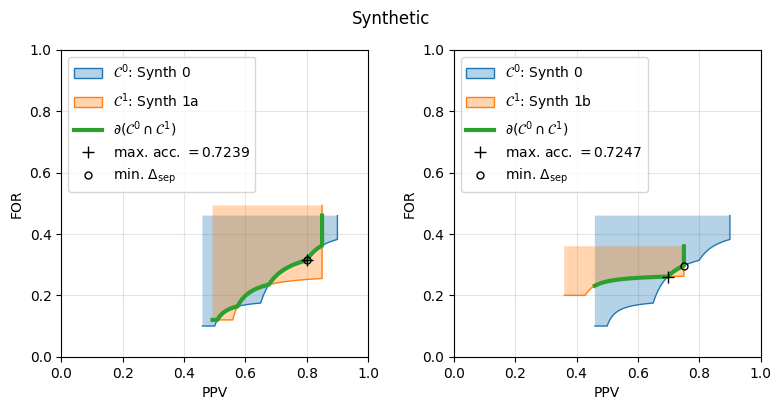

In [ ]:
# Figure

fig, axs = plt.subplots(1, 2, figsize=(8, 4))

for ax, result in zip(axs, [result_a, result_b]):
  plot_feasible_regions(ax, result)

fig.suptitle('Synthetic')
fig.tight_layout()

## Calibration-error experiment

In [ ]:
# Compute selection rule statistics

def get_stats_from_rules(rules, dists, prob_a1):
  ps, qs, accs = [], [], []

  for rule, dist in zip(rules, dists):
    scores = dist.s_input
    weights = dist.w_input
    rule = np.asarray(rule)

    mu = weights.dot(rule)
    pi = weights.dot(scores)

    p = np.sum(scores * weights * rule) / mu
    q = np.sum(scores * weights * (1 - rule)) / (1 - mu)
    acc = 1 - pi + mu * (2 * p - 1)

    ps.append(p)
    qs.append(q)
    accs.append(acc)

  acc = (1 - prob_a1) * accs[0] + prob_a1 * accs[1]

  return ps, qs, acc

In [ ]:
np.random.seed(42)

n_reps = 100
n_epsilons = 10
epsilons = np.linspace(0.01, 0.1, n_epsilons)

true_dists = [dist0, dist1a]

weights = [dist.w_input for dist in true_dists]
all_scores = np.r_[true_dists[0].s_input, true_dists[1].s_input]
m = [len(dist.s_input) for dist in true_dists]

ps = np.full((n_reps, n_epsilons, 2), np.nan)
qs = np.full((n_reps, n_epsilons, 2), np.nan)
accs = np.full((n_reps, n_epsilons), np.nan)

for e, epsilon in enumerate(tqdm(epsilons)):
  for i in range(n_reps):
    while True:
      noise = np.random.uniform(-1, 1, size=m[0] + m[1])
      noise = epsilon * noise / np.abs(noise).max()
      noisy_scores = all_scores + noise

      if np.all((noisy_scores >= 0) & (noisy_scores <= 1)):
        break

    noisy_dists = [
        GroupScoreDistribution(noisy_scores[:m[0]], weights[0]),
        GroupScoreDistribution(noisy_scores[m[0]:], weights[1])]

    # Optimize using perturbed scores, then evaluate the induced rule on
    # the original calibrated distributions.
    noisy_result = trace_intersection(
        noisy_dists[0], noisy_dists[1], prob_a1)

    noisy_rules = [
        noisy_dist.selection_rule(
            noisy_result.max_acc.p, noisy_result.max_acc.q)
        for noisy_dist in noisy_dists]

    ps_, qs_, acc_ = get_stats_from_rules(
        noisy_rules, true_dists, prob_a1)

    ps[i, e] = ps_
    qs[i, e] = qs_
    accs[i, e] = acc_

p_gap = np.abs(ps[..., 0] - ps[..., 1])
q_gap = np.abs(qs[..., 0] - qs[..., 1])

100%|██████████| 10/10 [00:04<00:00,  2.28it/s]


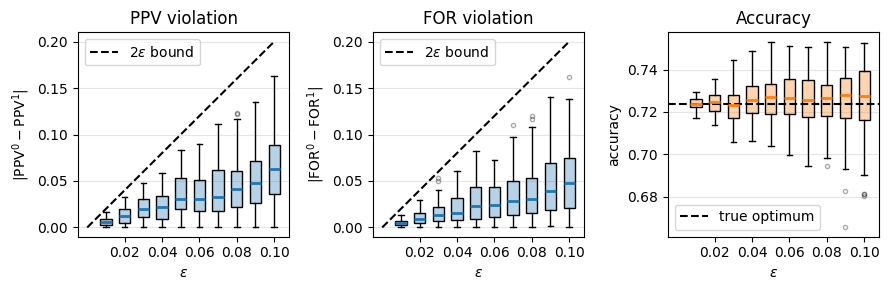

In [ ]:
# Figure

fig, axs = plt.subplots(1, 3, figsize=(9, 3), sharex=True)

styled_boxplot(axs[0], p_gap, epsilons, 'violation')
axs[0].plot([0, max(epsilons)], [0, 2 * max(epsilons)],
            '--', c='black', label=r'$2\epsilon$ bound')
axs[0].set_ylabel(r'$|\mathrm{PPV}^0-\mathrm{PPV}^1|$')
axs[0].set_title('PPV violation')

styled_boxplot(axs[1], q_gap, epsilons, 'violation')
axs[1].plot([0, max(epsilons)], [0, 2 * max(epsilons)],
            '--', c='black', label=r'$2\epsilon$ bound')
axs[1].set_ylabel(r'$|\mathrm{FOR}^0-\mathrm{FOR}^1|$')
axs[1].set_title('FOR violation')
axs[1].sharey(axs[0])

styled_boxplot(axs[2], accs, epsilons, 'accuracy')
axs[2].axhline(result_a.max_acc.value,
               ls='--', c='black', label='true optimum')
axs[2].set_ylabel('accuracy')
axs[2].set_title('Accuracy')

for ax in axs:
  ax.set_xticks(epsilons[1::2])
  ax.set_xlabel(r'$\epsilon$')
  ax.grid(axis='y', alpha=0.33)
  ax.legend()

fig.tight_layout()